In [ ]:

from LLM_INTERNALIZATION import config
from LLM_INTERNALIZATION.amazon import train_thinking
from LLM_INTERNALIZATION.ml import sample_sequence_data

import importlib

importlib.reload(config)
importlib.reload(train_thinking)
importlib.reload(sample_sequence_data)

BASE_DIR: /usr/local/google/home/stellasyan/Documents/llm_internalization


/usr/local/google/home/stellasyan/miniconda3/envs/torch_think_test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version 2.9.0+cu128 for torchao version 0.15.0             Please see https://github.com/pytorch/ao/issues/2919 for more info


BASE_DIR: /usr/local/google/home/stellasyan/Documents/llm_internalization


<module 'sample_sequence_data' from '/usr/local/google/home/stellasyan/Documents/llm_internalization/ml/sample_sequence_data.py'>

['train/loss', 'train/grad_norm', 'train/learning_rate', 'train/epoch', 'eval/loss', 'eval/runtime', 'eval/samples_per_second', 'eval/steps_per_second', 'train/eval/recall_1', 'train/eval/ndcg_1', 'train/eval/recall_5', 'train/eval/ndcg_5', 'train/eval/recall_10', 'train/eval/ndcg_10', 'train/step', 'train/train_runtime', 'train/train_samples_per_second', 'train/train_steps_per_second', 'train/total_flos', 'train/train_loss']
['train/loss', 'train/grad_norm', 'train/learning_rate', 'train/epoch', 'eval/loss', 'eval/runtime', 'eval/samples_per_second', 'eval/steps_per_second', 'train/eval/recall_1', 'train/eval/ndcg_1', 'train/eval/recall_5', 'train/eval/ndcg_5', 'train/eval/recall_10', 'train/eval/ndcg_10', 'train/step', 'train/train_runtime', 'train/train_samples_per_second', 'train/train_steps_per_second', 'train/total_flos', 'train/train_loss']
['train/loss', 'train/grad_norm', 'train/learning_rate', 'train/epoch', 'eval/loss', 'eval/runtime', 'eval/samples_per_second', 'eval/steps_

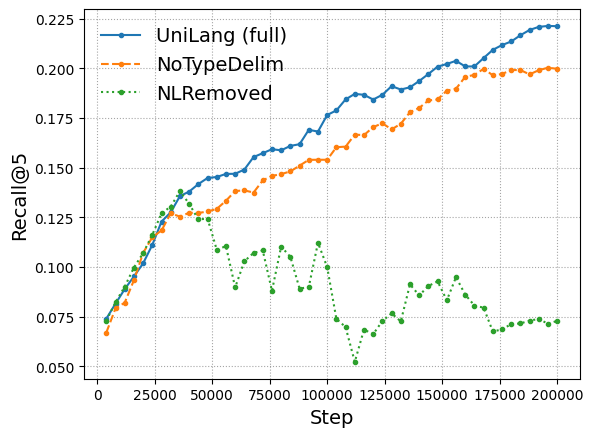

In [ ]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

def smooth(values, weight=0.9):
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed


def filter_by_step_interval(steps, values, interval):
    filtered_steps = []
    filtered_values = []

    for s, v in zip(steps, values):
        if s % interval == 0:
            filtered_steps.append(s)
            filtered_values.append(v)

    return filtered_steps, filtered_values



def load_scalar_from_event(log_dir, tag, smooth_weight=None):
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()
    print(ea.Tags()["scalars"])

    if tag not in ea.Tags().get("scalars", []):
        raise ValueError(f"Tag '{tag}' not found.")

    scalar_events = ea.Scalars(tag)

    # for e in scalar_events:
    #     print(e.step, e.value)

    # Sort by step
    scalar_events = sorted(scalar_events, key=lambda x: x.step)

    steps = []
    values = []

    last_step = -1
    for e in scalar_events:
        if e.step > last_step:  # enforce monotonic increase
            steps.append(e.step)
            values.append(e.value)
            last_step = e.step

    if smooth_weight is not None and values:
        values = smooth(values, weight=smooth_weight)

    return steps, values


tag = "train/eval/recall_5"  # "train/eval/ndcg_5", "train/eval/recall_5"
smooth_weight=0.58
if tag == "train/eval/recall_5":
    label = "Recall@5"
elif tag ==  "train/eval/ndcg_5":
    label = "NDCG@5"
elif tag ==  "train/eval/ndcg_10":
    label = "NDCG@10"


# UniLang
log_dir = "/usr/local/google/home/stellasyan/Documents/llm_internalization/data/runs/ML_train_think_pred/20m_unilang"
steps, values = load_scalar_from_event(log_dir, tag, smooth_weight)

# Downsample UniLang (2k logging → 4k logging)
steps, values = filter_by_step_interval(steps, values, 4000)

# no_tag
log_dir = "/usr/local/google/home/stellasyan/Documents/llm_internalization/data/runs/ML_train_think_pred/abl_notag_20m_0.0002_weight_decay0.005_bs16_acc_step1_warmup_2000_lora_rank32_lora_ratio2.0_lora_dropout0.05_total_steps200000_0"
steps_notag, values_notag = load_scalar_from_event(log_dir, tag, smooth_weight)

# sid only
log_dir = "/usr/local/google/home/stellasyan/Documents/llm_internalization/data/runs/ML_train_think_pred/abl_sid_20m_0.0002_weight_decay0.005_bs16_acc_step1_warmup_2000_lora_rank32_lora_ratio2.0_lora_dropout0.05_total_steps200000_0"
steps_sid, values_sid = load_scalar_from_event(log_dir, tag, smooth_weight)


# Create figure and axes
fig, ax = plt.subplots()

# Plot
ax.plot(steps, values, label="UniLang (full)", marker='.')
ax.plot(steps_notag, values_notag, alpha=1, marker='.', linestyle='--', label="NoTypeDelim")
ax.plot(steps_sid, values_sid, alpha=1, marker='.', linestyle=':', label="NLRemoved")

# Labels
ax.set_xlabel("Step",fontsize=14)
ax.set_ylabel(label, fontsize=14)

# Transparent figure and axes
fig.patch.set_alpha(0.0)   # figure background
ax.set_facecolor('none')    # axes background

# Grid — visible on transparent background
ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.7, zorder=0)

# Legend — bigger font and transparent
legend = ax.legend(fontsize=14)  # larger legend text
legend.get_frame().set_alpha(0.0)  # transparent legend box
legend.get_frame().set_edgecolor('none')  # remove border

plt.show()

In [3]:
values[-10:]

[0.14850425720214844,
 0.14563395082950592,
 0.150739386677742,
 0.14925245940685272,
 0.1492328941822052,
 0.14790406823158264,
 0.14876900613307953,
 0.1469692587852478,
 0.14841949939727783,
 0.1492767333984375]